# 02 · Grafo de capacidades productivas: comunidades, puentes y oportunidades de mercado

**Fase CRISP-DM:** modelado descriptivo (§1–4) y evaluación de su utilidad predictiva (§5). Responde la
pregunta 2 del proyecto: qué productos comparten capacidades y hacia qué mercados puede diversificarse Chile.

**Pregunta:** ¿qué relaciones del comercio chileno solo se ven con un grafo? Y la pregunta más importante:
**¿ese grafo aporta información verificable**, o es solo una visualización atractiva?

### Por qué este grafo (y no otros)

Un grafo se justifica cuando importan las **conexiones indirectas** (A se relaciona con C a través de B).
Con los datos disponibles:

| Alternativa | Decisión | Razón |
|---|---|---|
| Red Chile → países | Descartada | Es una estrella con un solo centro: una tabla dibujada como red |
| Red de empresas en el tiempo | Descartada | Los IDs de empresa se renumeran cada mes (ver `01_eda` §8) |
| *Product Space* clásico (Hidalgo & Hausmann 2007) | Descartada | Requiere qué exporta **cada país del mundo**; solo tenemos a Chile |
| Empresas importadoras ↔ exportadoras | Descartada | Las numeraciones de importadores y exportadores son independientes |
| **Red de productos por capacidades compartidas** | Elegida | Dos productos se relacionan si **las mismas empresas** los exportan. La empresa se usa solo **dentro de cada mes**, lo que es válido |

**Intuición:** si muchas empresas que exportan uva también exportan arándanos, ambos productos comparten
capacidades (cadena de frío, packaging, logística, know-how agrícola). La teoría de diversificación
(*relatedness*; Hidalgo et al. 2007, Neffke et al. 2011) predice que las economías se expanden hacia
productos y mercados **cercanos** a lo que ya hacen. Eso lo podemos **probar** con datos.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, adjusted_rand_score as ARI, normalized_mutual_info_score as NMI
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict

from comercio_chile import viz, graph as g, activation as A
from comercio_chile.config import PROCESSED, REFERENCES
from comercio_chile.data import country_names, hs_chapters

viz.setup()
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 70)
PAIS, CAP = country_names(), hs_chapters()
ETQ = pd.read_csv(REFERENCES / "codigos" / "hs6_etiquetas_2025.csv", dtype=str).set_index("hs6").etiqueta
SECCION = pd.read_csv(REFERENCES / "codigos" / "sa_capitulos.csv", dtype=str).set_index("capitulo").seccion
panel = pd.read_parquet(PROCESSED / "panel_exportaciones.parquet")
Y2025 = A.months("2025-01", 12)

## 1. De transacciones a una matriz empresa-mes × producto

Para cada mes de 2025 marcamos qué productos (HS6) exportó cada empresa. Hay que tomar dos decisiones.

**Decisión 1. Umbral mínimo de valor.** Una exportadora de fruta que envía US$ 300 en repuestos crearía un
vínculo espurio "fruta–repuestos". ¿Cuánto cuesta filtrar esos casos?

In [2]:
fp_all = g.firm_products(Y2025, min_value=0)
rows = []
for thr in [0, 1_000, 5_000, 10_000, 20_000]:
    f = fp_all[fp_all.valor >= thr]
    k = f.groupby(["periodo", "empresa"]).hs6.nunique()
    rows.append({"umbral US$": thr, "pares empresa-mes-producto": len(f),
                 "% pares eliminados": 100 * (1 - len(f) / len(fp_all)),
                 "% valor conservado": 100 * f.valor.sum() / fp_all.valor.sum(),
                 "% empresas-mes monoproducto": 100 * (k == 1).mean()})
pd.DataFrame(rows).set_index("umbral US$").round(2)

,pares empresa-mes-producto,% pares eliminados,% valor conservado,% empresas-mes monoproducto
umbral US$,,,,
0,99686,0.00,100.00,54.50
1000,78419,21.33,99.99,57.42
5000,60019,39.79,99.95,61.05
10000,51313,48.53,99.89,63.04
20000,42910,56.95,99.77,64.82


Con **US$ 5.000** se eliminan ~40% de los pares, pero solo ~0,05% del valor: es un filtro de ruido casi
gratuito. Más adelante (§5.3) se verifica que el resultado no depende de este valor exacto.

**Decisión 2. Empresas generalistas.** Una empresa-mes con *k* productos genera *k(k−1)/2* pares
co-ocurrentes. ¿Qué tan desigual es eso?

In [3]:
fp = g.firm_products(Y2025, min_value=5_000)
k = fp.groupby(["periodo", "empresa"]).hs6.nunique()
pairs = k * (k - 1) / 2
pd.DataFrame({f"> {t} productos": {"% de empresas-mes": 100 * (k > t).mean(),
                                    "% de los pares co-ocurrentes": 100 * pairs[k > t].sum() / pairs.sum()}
              for t in [10, 20, 50]}).T.round(1)

,% de empresas-mes,% de los pares co-ocurrentes
> 10 productos,0.9,53.5
> 20 productos,0.2,38.4
> 50 productos,0.0,23.5


**El 0,9% de las empresas-mes (las que exportan más de 10 productos) genera ~54% de los pares.** Son sobre
todo distribuidores de maquinaria y repuestos (capítulos 84/85/73) con hasta 85 productos en un mes. Sin
corrección, el grafo reflejaría sus catálogos y no capacidades productivas.

**Corrección (Newman 2001):** cada empresa-mes aporta un peso **1/(k−1)** a cada par: reparte "una unidad"
de vínculo entre sus productos, como en las redes de coautoría, donde un artículo con 100 autores crea
vínculos débiles entre ellos. La elección entre ponderar o no se hace **empíricamente** en §5, no por
intuición.

**Proximidad** entre productos (versión ponderada del *Product Space*):

$$\varphi_{pq} = \frac{\sum_f w_f\, X_{fp} X_{fq}}{\max(N_p, N_q)}, \qquad w_f = \frac{1}{k_f - 1}$$

donde $N_p$ = n.º de empresas-mes que exportan $p$. Dividir por el **máximo** hace la medida simétrica y
conservadora: dos productos solo quedan muy próximos si cada uno es frecuente entre los exportadores
del otro. Se exige $N_p \geq 10$, porque con menos observaciones la proximidad es puro ruido.

In [4]:
prox = g.proximity(fp, min_obs=10, weighting="newman")
G = g.to_graph(prox)
Gc = G.subgraph([n for n in G if G.degree(n) > 0]).copy()
valor25 = panel[(panel.segmento == "bienes") & panel.periodo.astype(str).isin(Y2025)].groupby("hs6").valor_usd.sum()
w = np.array([d["phi"] for *_, d in Gc.edges(data=True)])
pd.Series({
    "productos (nodos)": G.number_of_nodes(),
    "productos aislados": G.number_of_nodes() - Gc.number_of_nodes(),
    "% del valor exportado 2025 cubierto": 100 * valor25.reindex(prox.products).sum() / valor25.sum(),
    "aristas (φ > 0)": Gc.number_of_edges(),
    "densidad del grafo": nx.density(Gc),
    "componentes conexas": nx.number_connected_components(Gc),
    "grado mediano": float(np.median([d for _, d in Gc.degree()])),
    "φ mediana": np.median(w), "φ p99": np.quantile(w, .99),
}).round(4).to_frame("valor")

,valor
productos (nodos),1137.0000
productos aislados,21.0000
% del valor exportado 2025 cubierto,99.2832
aristas (φ > 0),21008.0000
densidad del grafo,0.0338
componentes conexas,4.0000
grado mediano,21.0000
φ mediana,0.0030
φ p99,0.1377


Es un grafo **disperso** (3% de las aristas posibles) que cubre el 99% del valor exportado. Cada producto
se conecta en mediana con ~20 otros, y la mayoría de las proximidades son débiles. Las fuertes son pocas.
Esta es la estructura típica de una red de capacidades.

## 2. Comunidades: los ecosistemas productivos de Chile

Usamos **Louvain**, que busca la partición que maximiza la **modularidad** (cuánto más densas son las
conexiones dentro de los grupos que lo esperado por azar). Ventajas frente a *k-means* o el clustering
jerárquico: no exige fijar el número de grupos y escala bien en grafos dispersos.

Tiene dos debilidades conocidas, que **controlamos**: (1) es **aleatorio**, así que medimos la
estabilidad entre semillas; (2) tiene un parámetro de **resolución** (grupos grandes vs pequeños), así que
probamos varios valores.

In [5]:
rows = []
for res in [0.5, 1.0, 1.5, 2.0]:
    parts = [g.communities(Gc, res, seed=s) for s in range(10)]
    p0 = parts[0]
    mod = nx.community.modularity(Gc, [set(p0[p0 == c].index) for c in p0.unique()], weight="phi")
    nodes = p0.index
    rows.append({"resolución": res, "comunidades": p0.nunique(), "con ≥10 productos": int((p0.value_counts() >= 10).sum()),
                 "modularidad": mod,
                 "estabilidad (ARI medio entre 10 semillas)": np.mean([ARI(p0.sort_index(), p.sort_index()) for p in parts[1:]]),
                 "NMI vs sección SA": NMI(SECCION.reindex(nodes.str[:2]).fillna("?"), p0),
                 "NMI vs capítulo SA": NMI(nodes.str[:2], p0)})
pd.DataFrame(rows).set_index("resolución").round(3)

,comunidades,con ≥10 productos,modularidad,estabilidad (ARI medio entre 10 semillas),NMI vs sección SA,NMI vs capítulo SA
resolución,,,,,,
0.5,20,13,0.743,0.931,0.481,0.514
1.0,30,19,0.757,0.904,0.484,0.555
1.5,38,24,0.750,0.862,0.510,0.592
2.0,43,31,0.741,0.828,0.507,0.599


**Cómo leer esta tabla:**
- **Modularidad** ≈ 0,75 en todas las resoluciones. Sobre 0,3 ya se considera estructura comunitaria
  significativa: aquí es muy fuerte.
- **Estabilidad:** el ARI (*Adjusted Rand Index*) mide qué tan parecidas son dos particiones (1 = idénticas,
  0 = parecido de azar). Con resolución 1,0, diez semillas producen particiones casi iguales (ARI ≈ 0,90).
- **NMI vs clasificación arancelaria ≈ 0,5:** las comunidades se parecen a la clasificación oficial, **pero
  no son lo mismo**. Esa diferencia es justamente la información nueva que aporta el grafo.

**Elección: resolución 1,0**, que maximiza la modularidad con estabilidad alta. Resoluciones mayores dan más
grupos, pero menos estables.

In [6]:
com = g.communities(Gc, 1.0, seed=42)
NOMBRES = {  # nombre interpretativo según el producto principal de la comunidad
    "260300": "Gran minería (cobre, oro)", "080929": "Fruticultura fresca", "283691": "Salares (litio, nitratos)",
    "030441": "Acuicultura (salmón)", "280120": "Química (yodo, metanol)", "470329": "Forestal: celulosa y papel",
    "220421": "Vino", "260111": "Hierro y químicos inorgánicos", "440711": "Forestal: madera",
    "020329": "Cárnicos", "740811": "Cobre elaborado y chatarra", "401110": "Plásticos, envases y neumáticos",
    "200290": "Agroindustria procesada", "120991": "Semillas",
    "271019": "Manufactura diversificada (regional)", "300490": "Farmacéutica y algas",
}
goods25 = panel[(panel.segmento == "bienes") & panel.periodo.astype(str).isin(Y2025) & ~panel.pseudo_pais]
total25 = valor25.sum()
rows = []
for c, idx in com.groupby(com).groups.items():
    nodes = list(idx)
    v = valor25.reindex(nodes).fillna(0).sort_values(ascending=False)
    dest = goods25[goods25.hs6.isin(nodes)].groupby("pais").valor_usd.sum().sort_values(ascending=False)
    caps = pd.Series([n[:2] for n in nodes]).value_counts(normalize=True)
    rows.append({"comunidad": c, "nombre": NOMBRES.get(v.index[0], "Otra · " + ETQ.get(v.index[0], v.index[0]).title()),
                 "productos": len(nodes), "% valor 2025": 100 * v.sum() / total25,
                 "productos principales": " · ".join(ETQ.get(h, h).title() for h in v.index[:3]),
                 "capítulos SA distintos": caps.size,
                 "capítulos principales": ", ".join(f"{CAP.get(k_, k_)} {p:.0%}" for k_, p in caps.head(2).items()),
                 "% a China": 100 * dest.get("336", 0) / dest.sum(),
                 "destino #1": PAIS.get(dest.index[0], dest.index[0]).title()})
comunidades = pd.DataFrame(rows).sort_values("% valor 2025", ascending=False).set_index("comunidad")
inside = sum(d["phi"] for u, v_, d in Gc.edges(data=True) if com[u] == com[v_]) / w.sum()
print(f"Peso de las aristas DENTRO de comunidades: {inside:.1%}")
comunidades.head(16).round(1)

Peso de las aristas DENTRO de comunidades: 85.1%


,nombre,productos,% valor 2025,productos principales,capítulos SA distintos,capítulos principales,% a China,destino #1
comunidad,,,,,,,,
13,"Gran minería (cobre, oro)",24,58.5,Concentrado De Cobre · Catodo De Cobre · Oro Aleado,9,"Minerales metalíferos 29%, Metales preciosos y joyería 21%",46.6,China
6,Fruticultura fresca,52,9.6,Cerezas Frescas · Uvas Frescas · Manzanas Frescas,11,"Frutas y frutos secos 58%, Hortalizas 13%",36.4,China
5,Acuicultura (salmón),60,8.7,Filete De Salmon Atlantico · Filete De Salmon Atlantico · Salmon C...,6,"Pescados y mariscos 75%, Preparaciones de carne y pescado 18%",7.3,Estados Unidos De América
18,Forestal: celulosa y papel,11,3.5,Celulosa Blanqueada Eucaliptus · Celulosa Blanqueada · Cartulina M...,2,"Papel y cartón 64%, Pasta de celulosa 36%",58.4,China
7,"Salares (litio, nitratos)",48,3.2,Carbonato De Litio · Nitrato De Potasio · Hidroxido De Litio,11,"Aceites esenciales y cosméticos 19%, Jabones y detergentes 15%",48.1,China
4,"Química (yodo, metanol)",79,2.2,Yodo Crudo · Metanol · Yoduro De Potasio,18,"Plástico 22%, Tintas y pinturas 16%",33.6,China
8,Forestal: madera,48,2.1,Madera Simplemente Aserrada · Plywood · Madera De Pino Radiata,9,"Madera 50%, Manufacturas diversas de metal 17%",5.2,Estados Unidos De América
2,Agroindustria procesada,90,1.8,Pasta De Tomate · Base Bebida · Pure De Manzana,25,"Conservas de hortalizas y frutas 18%, Preparaciones alimenticias d...",1.0,Estados Unidos De América
16,Vino,16,1.6,Vino · Vino · Jugo,3,"Bebidas y vinos 88%, Conservas de hortalizas y frutas 6%",9.6,Brasil


**Las comunidades son ecosistemas productivos reconocibles, y cruzan la clasificación oficial:**
- **Gran minería** reúne concentrado y cátodos de cobre con **oro**: el oro es subproducto de la misma minería.
- **Salares** reúne **carbonato de litio y nitrato de potasio** (capítulos 28 y 31), que vienen de los mismos
  salares del norte.
- **Celulosa** aparece junto a **cartulina** (capítulos 47 y 48): integración vertical de las forestales.
- **Madera aserrada** forma una comunidad **separada** de la celulosa, con otros mercados (EE.UU. vs China).
- **Manufactura diversificada**, la comunidad más grande en número de productos (265: maquinaria, repuestos,
  electrónica, combustibles reexportados), pesa poco en valor (1,4%) y va a **mercados vecinos** (Perú,
  Bolivia): el patrón típico de exportación de manufacturas a la región.
- Las comunidades pequeñas sin un rubro claro se nombran "Otra · producto principal": nombrarlas con más
  detalle sería sobreinterpretar.

Ningún algoritmo recibió estas categorías: emergen solo de **qué productos exportan las mismas empresas**.

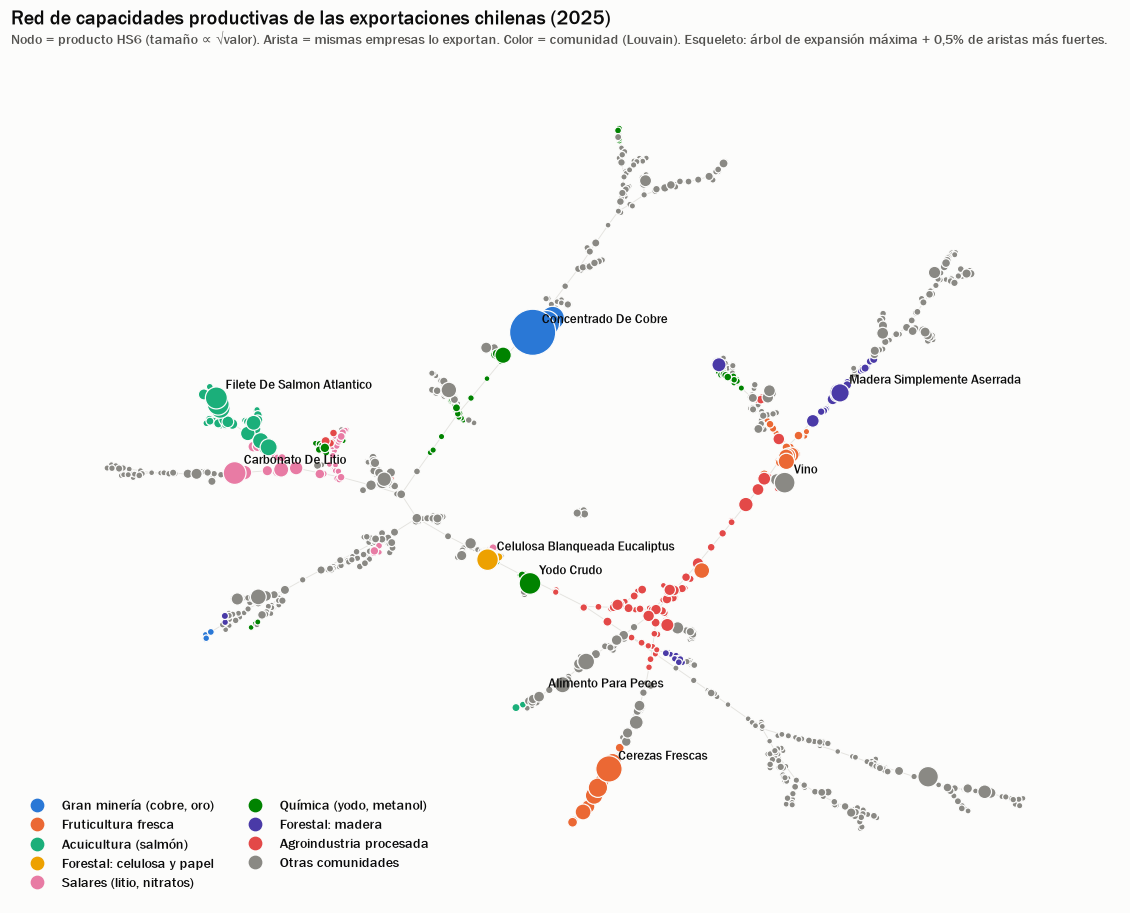

In [7]:
top_c = comunidades.index[:8]
color = {c: viz.SERIES[i] for i, c in enumerate(top_c)}
B = g.backbone(Gc, extra_quantile=0.995)
pos = nx.spring_layout(B, k=0.06, iterations=300, seed=42, weight="phi")
vmax = valor25.reindex(list(B)).max()

fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
nx.draw_networkx_edges(B, pos, ax=ax, edge_color=viz.GRID, width=0.6)
nodes = list(B)
cols = [color.get(com.get(n), viz.NEUTRAL) for n in nodes]
sizes = [12 + 900 * np.sqrt(valor25.get(n, 0) / vmax) for n in nodes]
order = np.argsort(sizes)
ax.scatter([pos[nodes[i]][0] for i in order], [pos[nodes[i]][1] for i in order], s=[sizes[i] for i in order],
           c=[cols[i] for i in order], edgecolors=viz.SURFACE, linewidths=0.8, zorder=3)
for h in ["260300", "080929", "030441", "470329", "283691", "220421", "440711", "230990", "280120"]:
    if h in pos:
        ax.annotate(ETQ.get(h, h).title(), pos[h], xytext=(6, 6), textcoords="offset points", fontsize=8.5,
                    color=viz.TEXT, fontweight="bold", zorder=4)
handles = [plt.Line2D([], [], marker="o", ls="", color=color[c], markersize=8, label=comunidades.loc[c, "nombre"]) for c in top_c]
handles.append(plt.Line2D([], [], marker="o", ls="", color=viz.NEUTRAL, markersize=8, label="Otras comunidades"))
ax.legend(handles=handles, loc="lower left", fontsize=9, ncol=2)
ax.set_title("Red de capacidades productivas de las exportaciones chilenas (2025)")
viz.subtitle(ax, "Nodo = producto HS6 (tamaño ∝ √valor). Arista = mismas empresas lo exportan. Color = comunidad (Louvain). "
             "Esqueleto: árbol de expansión máxima + 0,5% de aristas más fuertes.")
viz.save(fig, "09_red_capacidades"); fig

## 3. Exposición por ecosistema

Con las comunidades se puede responder una pregunta de riesgo que la tabla por capítulo responde mal:
**¿qué ecosistemas productivos dependen de un solo mercado?**

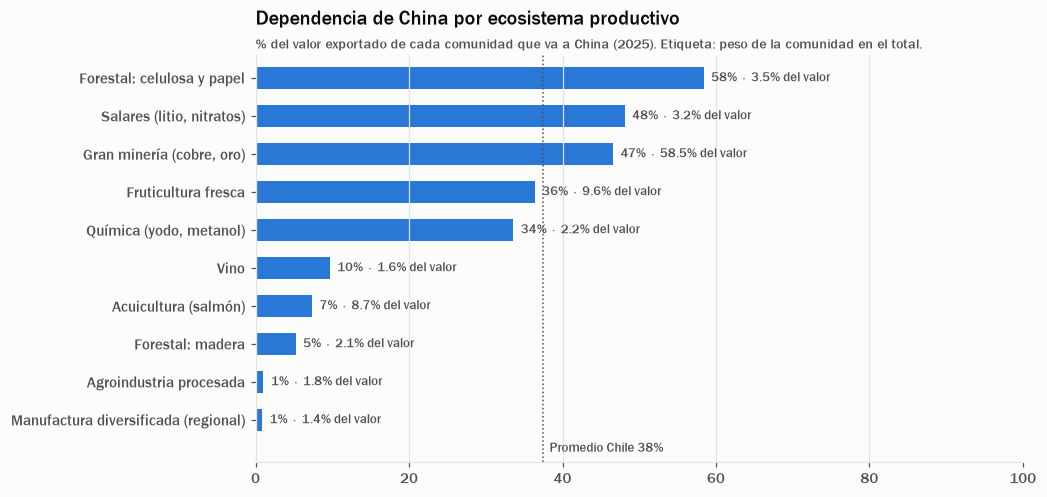

In [8]:
ex = comunidades.head(10).sort_values("% a China")
china_total = 100 * goods25[goods25.pais == "336"].valor_usd.sum() / goods25.valor_usd.sum()
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(ex.nombre, ex["% a China"], color=viz.EXPORT, height=0.6)
for y, (v, s) in enumerate(zip(ex["% a China"], ex["% valor 2025"])):
    ax.text(v + 1, y, f"{v:.0f}%  ·  {s:.1f}% del valor", va="center", fontsize=8.5, color=viz.TEXT_2)
ax.axvline(china_total, color=viz.TEXT_2, ls=":", lw=1)
ax.text(china_total + 0.8, -0.75, f"Promedio Chile {china_total:.0f}%", fontsize=8.5, color=viz.TEXT_2, va="center")
ax.set_ylim(-1.1, len(ex) - 0.4)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.set_xlim(0, 100)
ax.set_title("Dependencia de China por ecosistema productivo")
viz.subtitle(ax, "% del valor exportado de cada comunidad que va a China (2025). Etiqueta: peso de la comunidad en el total.")
viz.save(fig, "10_exposicion_china"); fig

**Lectura:** la minería, la celulosa y los salares (litio), que juntos son más del 65% del valor exportado,
envían cerca de la mitad o más a China. La acuicultura, la madera y la agroindustria están mucho más
diversificadas hacia EE.UU., Japón y Latinoamérica. Un shock de demanda china no golpea a "las
exportaciones" en general: golpea a ecosistemas específicos, y el grafo permite identificarlos.

### 3.1 Red bipartita ecosistema–mercado

Una red **bipartita** tiene dos tipos de nodos y solo conecta nodos de tipos distintos: aquí, **ecosistemas
productivos** (las comunidades de la §2) con **países de destino**. Una red producto–país completa
(1.137 productos × ~180 países) tendría decenas de miles de aristas y sería ilegible. Por eso se agregan los
productos en sus ecosistemas, que es justamente lo que aporta el grafo de capacidades, y se muestran los 12
mercados principales.

In [9]:
top_eco = list(comunidades.index[:8])
eco_color = {comunidades.loc[c, "nombre"]: viz.SERIES[i] for i, c in enumerate(top_eco)}
OTROS_E, RESTO = "Otros ecosistemas", "Resto del mundo"

bip = goods25.assign(com=goods25.hs6.map(com))
bip["eco"] = np.where(bip.com.isin(top_eco), bip.com.map(comunidades["nombre"]), OTROS_E)
top_pais = bip.groupby("pais").valor_usd.sum().nlargest(12).index
bip["destino"] = np.where(bip.pais.isin(top_pais), bip.pais.map(lambda c: PAIS.get(c, c).title()), RESTO)
flujos = bip.groupby(["eco", "destino"]).valor_usd.sum().div(1e6).rename("MMUSD").reset_index()

# Grafo bipartito explícito (networkx) para calcular métricas por nodo
BP = nx.Graph()
BP.add_nodes_from(flujos.eco.unique(), lado="ecosistema")
BP.add_nodes_from(flujos.destino.unique(), lado="mercado")
BP.add_weighted_edges_from(flujos.itertuples(index=False, name=None))
assert nx.is_bipartite(BP)

# Diversificación de cada mercado: número efectivo de ecosistemas = 1 / Σ s²  (inverso del HHI)
sh = flujos.assign(s=flujos.MMUSD / flujos.groupby("destino").MMUSD.transform("sum"))
merc = sh.groupby("destino").agg(MMUSD=("MMUSD", "sum"), n_efectivo=("s", lambda x: 1 / (x ** 2).sum()))
principal = sh.loc[sh.groupby("destino").s.idxmax()].set_index("destino")
merc["ecosistema principal"] = principal.eco
merc["% del principal"] = 100 * principal.s
merc.sort_values("MMUSD", ascending=False).round(2)

,MMUSD,n_efectivo,ecosistema principal,% del principal
destino,,,,
China,38675.22,1.84,"Gran minería (cobre, oro)",72.63
Estados Unidos De América,16837.24,3.17,"Gran minería (cobre, oro)",51.08
Resto del mundo,15316.78,5.36,"Gran minería (cobre, oro)",26.17
Japon,8302.64,1.84,"Gran minería (cobre, oro)",71.71
Brasil,4824.64,3.18,"Gran minería (cobre, oro)",49.78
Corea Del Sur,4724.27,2.27,"Gran minería (cobre, oro)",64.55
India,3927.52,1.39,"Gran minería (cobre, oro)",84.44
Países Bajos,2013.88,4.12,"Gran minería (cobre, oro)",40.27
España,1941.23,2.76,"Gran minería (cobre, oro)",55.31


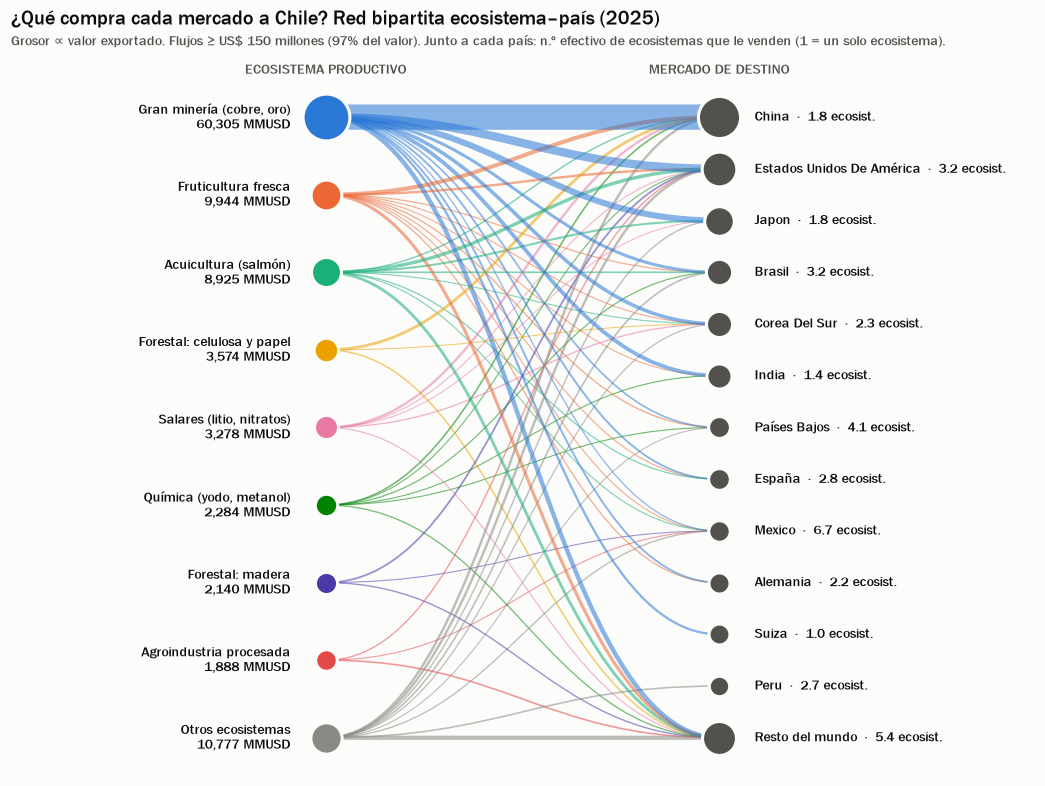

In [10]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch

eco_order = [comunidades.loc[c, "nombre"] for c in top_eco] + [OTROS_E]
dest_tot = flujos.groupby("destino").MMUSD.sum()
dest_order = [d for d in dest_tot.sort_values(ascending=False).index if d != RESTO] + [RESTO]
eco_tot = flujos.groupby("eco").MMUSD.sum()
y_e = {e: 1 - i / (len(eco_order) - 1) for i, e in enumerate(eco_order)}
y_d = {d: 1 - i / (len(dest_order) - 1) for i, d in enumerate(dest_order)}
MIN_FLUJO = 150  # MMUSD
vis = flujos[flujos.MMUSD >= MIN_FLUJO].sort_values("MMUSD")
wmax = vis.MMUSD.max()

fig, ax = plt.subplots(figsize=(12, 8.5))
ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
for r in vis.itertuples():
    y0, y1 = y_e[r.eco], y_d[r.destino]
    path = Path([(0, y0), (0.45, y0), (0.55, y1), (1, y1)], [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
    ax.add_patch(PathPatch(path, fc="none", ec=eco_color.get(r.eco, viz.NEUTRAL),
                           lw=0.6 + 16 * r.MMUSD / wmax, alpha=0.55, capstyle="butt"))
smax = max(eco_tot.max(), dest_tot.max())
for e in eco_order:
    ax.scatter(0, y_e[e], s=40 + 900 * np.sqrt(eco_tot[e] / smax), color=eco_color.get(e, viz.NEUTRAL),
               edgecolor=viz.SURFACE, linewidth=2, zorder=3)
    ax.text(-0.09, y_e[e], f"{e}\n{eco_tot[e]:,.0f} MMUSD", ha="right", va="center", fontsize=9, color=viz.TEXT)
for d in dest_order:
    ax.scatter(1, y_d[d], s=40 + 900 * np.sqrt(dest_tot[d] / smax), color=viz.TEXT_2,
               edgecolor=viz.SURFACE, linewidth=2, zorder=3)
    ax.text(1.09, y_d[d], f"{d}  ·  {merc.loc[d, 'n_efectivo']:.1f} ecosist.", ha="left", va="center", fontsize=9, color=viz.TEXT)
ax.text(0, 1.07, "ECOSISTEMA PRODUCTIVO", ha="center", fontsize=9, color=viz.TEXT_2, fontweight="bold")
ax.text(1, 1.07, "MERCADO DE DESTINO", ha="center", fontsize=9, color=viz.TEXT_2, fontweight="bold")
ax.set_xlim(-0.8, 1.8); ax.set_ylim(-0.06, 1.1)
ax.set_title("¿Qué compra cada mercado a Chile? Red bipartita ecosistema–país (2025)")
viz.subtitle(ax, f"Grosor ∝ valor exportado. Flujos ≥ US$ {MIN_FLUJO} millones ({100 * vis.MMUSD.sum() / flujos.MMUSD.sum():.0f}% del valor). "
                 "Junto a cada país: n.º efectivo de ecosistemas que le venden (1 = un solo ecosistema).")
viz.save(fig, "12_bipartita_ecosistema_pais"); fig

**Lectura:**
- **La relación con Asia es casi solo minera.** Para China y Japón, el número efectivo de ecosistemas es
  ~1,8 (73% minería); para India, 1,4 (84%). Una caída del precio del cobre afecta toda la relación
  comercial con esos países.
- **Suiza (≈1,0) es el caso extremo:** el 98% de lo que compra a Chile es **oro** (gran minería) para sus
  refinerías. Este patrón no se ve en un ranking de destinos y aparece de inmediato en la bipartita.
- **Los mercados diversificados son América:** EE.UU. y Brasil (~3,2) compran cobre, pero también salmón,
  fruta y madera. **México (6,7)** es el más diversificado de todos, y **Perú** compra sobre todo productos de
  ecosistemas menores, como la manufactura regional.
- **Implicancia de negocio:** la diversificación de mercados no se mide solo por **cuántos países** compran,
  sino por **cuántos ecosistemas** sostienen cada relación. Las relaciones con EE.UU., Brasil y México son
  más resilientes a un shock sectorial que la relación con China.

*Nota metodológica:* la bipartita es **descriptiva**. A diferencia de la densidad de relatedness (§5), no se
validó como predictiva. El número efectivo de ecosistemas es 1/HHI sobre las participaciones de cada
ecosistema en las compras de ese país.

## 4. Productos puente

El **coeficiente de participación** (Guimerà & Amaral 2005) mide si las conexiones de un producto se
concentran en su comunidad (P ≈ 0) o se reparten entre varias (P → 1). Los productos con P alto y valor
relevante son **eslabones entre ecosistemas**.

In [11]:
P = g.participation(Gc, com)
nombre_c = comunidades["nombre"]
puentes = pd.DataFrame({"producto": P.index.map(lambda h: ETQ.get(h, h).title()), "participación": P,
                        "valor 2025 (MMUSD)": valor25.reindex(P.index) / 1e6,
                        "su comunidad": com.reindex(P.index).map(nombre_c)})
puentes[puentes["valor 2025 (MMUSD)"] > 20].sort_values("participación", ascending=False).head(10).round(2)

,producto,participación,valor 2025 (MMUSD),su comunidad
150920,Aceite De Oliva,0.85,93.86,Agroindustria procesada
380892,Fungicida,0.79,55.43,Hierro y químicos inorgánicos
230990,Alimento Para Peces,0.74,63.17,Farmacéutica y algas
392310,Cajas Plasticas,0.72,23.87,Otra · Cigarrillos
732690,Cuerpos De Acero,0.65,26.46,Manufactura diversificada (regional)
854449,Cable De Cobre,0.64,61.07,Cobre elaborado y chatarra
830990,Tapas,0.59,21.27,"Plásticos, envases y neumáticos"
391990,Film Autoadhesivos,0.59,31.05,"Química (yodo, metanol)"
210690,Base Bebida,0.59,165.75,Agroindustria procesada
901890,Artroscopio,0.58,22.57,Otra · Cigarrillos


**Lectura:** los puentes tienen lógica de **cadena de suministro**:
- **Alimento para peces:** conecta la agroindustria (granos, harinas) con la acuicultura.
- **Cajas plásticas y film:** el packaging que comparten la fruta, la pesca y la manufactura.
- **Cable de cobre:** la industrialización del cobre, entre la minería y la manufactura.
- **Fungicidas:** química al servicio de la agricultura.

Son candidatos naturales para políticas de diversificación, porque ya conectan capacidades de varios sectores.

## 5. ¿El grafo aporta información verificable? Prueba fuera de tiempo

Hasta aquí, todo es descriptivo y "se ve bien". La prueba exigente es **predictiva**: si el grafo captura
capacidades reales, la **densidad de relatedness** debería anticipar qué pares (producto, país) **nuevos**
empieza a exportar Chile.

$$\omega_{pc} = \frac{\sum_q \varphi_{pq}\, M_{qc}}{\sum_q \varphi_{pq}}, \qquad M_{qc} = 1 \text{ si Chile ya exporta } q \text{ a } c$$

*"De los productos relacionados con p, ¿qué fracción ya se vende en el país c?"*

**Protocolo (sin data leakage):**

| Etapa | Grafo y presencia con | Activación en | Uso |
|---|---|---|---|
| Validación | 2024 | ene–ago 2025 | Elegir variante y umbrales |
| **Test** | 2025 | **ene–ago 2026** | Evaluación **única**, con configuración congelada |

- **Candidatos:** pares (p, c) que Chile **no** exportaba en la ventana base (< US$ 10 mil en 12 meses).
- **Activación:** ≥ US$ 10 mil en los meses siguientes. Es un evento raro (~1%).
- **Baseline sin grafo:** ubicuidad del producto (a cuántos países va), diversidad del país (cuántos
  productos compra) y el tamaño de ambos. Es un baseline **exigente**: productos populares y mercados
  abiertos ya explican mucho.
- **Métricas:** AUC y, sobre todo, **AP (average precision)**, la adecuada para eventos raros. Su
  referencia de azar es la tasa base (~0,01), no 0,5.

### 5.1 Validación: ¿ponderar por Newman o no?

In [12]:
base_v, targ_v = A.months("2024-01", 12), A.months("2025-01", 8)

def evaluate_cv(d, model_factory):
    out = {}
    for name, feats in [("baseline", A.BASELINE), ("baseline + grafo", A.WITH_GRAPH)]:
        p = cross_val_predict(model_factory(), d[feats], d.activa, cv=GroupKFold(5), groups=d.hs6, method="predict_proba")[:, 1]
        out[name] = p
    return out

gbm = lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42)
rows, val = [], {}
for wgt in ["none", "newman"]:
    d = A.build_dataset(panel, base_v, targ_v, weighting=wgt)
    preds = evaluate_cv(d, gbm)
    val[wgt] = (d, preds)
    r = {"ponderación": wgt, "candidatos": len(d), "tasa de activación": d.activa.mean(),
         "AUC densidad sola": roc_auc_score(d.activa, d.densidad), "AP densidad sola": average_precision_score(d.activa, d.densidad)}
    for k_, p in preds.items():
        r[f"AUC {k_}"] = roc_auc_score(d.activa, p); r[f"AP {k_}"] = average_precision_score(d.activa, p)
    rows.append(r)
pd.DataFrame(rows).set_index("ponderación").T.round(4)

ponderación,none,newman
candidatos,187449.0000,187449.0000
tasa de activación,0.0098,0.0098
AUC densidad sola,0.8747,0.8744
AP densidad sola,0.0825,0.0807
AUC baseline,0.9131,0.9131
AP baseline,0.1056,0.1056
AUC baseline + grafo,0.9222,0.9227
AP baseline + grafo,0.1235,0.1218


**Lectura:**
- La **densidad sola** ya tiene mucha señal: AP ≈ 0,08, unas **8 veces** la tasa base.
- El **baseline sin grafo es fuerte** (AUC ≈ 0,91), y por eso compararse contra él es indispensable.
- **Agregar la densidad mejora la AP en ~15% relativo.**
- Ponderar o no casi no cambia el resultado: es **robusto** a esa decisión. Se elige Newman por su mejor
  justificación teórica.

Se usa *GroupKFold* por producto: todos los pares de un producto quedan en el mismo fold, para que el
modelo no "memorice" el producto en entrenamiento y lo reconozca en validación.

### 5.2 ¿La mejora es real o ruido? Bootstrap por producto

In [13]:
d, preds = val["newman"]
y = d.activa.to_numpy()
rng = np.random.default_rng(42); prods = d.hs6.unique(); idx = d.groupby("hs6").indices
diff = np.array([average_precision_score(y[s], preds["baseline + grafo"][s]) - average_precision_score(y[s], preds["baseline"][s])
                 for s in (np.concatenate([idx[q] for q in rng.choice(prods, len(prods))]) for _ in range(300))])
print(f"ΔAP (grafo − baseline) en validación: {diff.mean():+.4f} | IC95% [{np.quantile(diff, .025):+.4f}, {np.quantile(diff, .975):+.4f}] | "
      f"réplicas con mejora: {(diff > 0).mean():.0%}")

ΔAP (grafo − baseline) en validación: +0.0165 | IC95% [+0.0089, +0.0241] | réplicas con mejora: 100%


Se remuestrean **productos**, no filas: los ~170 pares de un mismo producto no son independientes entre sí,
y remuestrear filas daría intervalos artificialmente estrechos (una forma sutil de sobreestimar la
confianza). El intervalo excluye el cero.

### 5.3 Sensibilidad a los umbrales (control de *p-hacking*)

Si la mejora apareciera solo con los umbrales exactos elegidos, sería sospechosa.

In [14]:
rows = []
for mv in [1_000, 5_000, 20_000]:
    for mo in [5, 10, 20]:
        dd = A.build_dataset(panel, base_v, targ_v, min_value=mv, min_obs=mo)
        pr = evaluate_cv(dd, lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=42))
        ap_b, ap_g = (average_precision_score(dd.activa, pr[k_]) for k_ in ["baseline", "baseline + grafo"])
        rows.append({"umbral valor": mv, "mín. obs.": mo, "productos": dd.hs6.nunique(),
                     "AP baseline": ap_b, "AP + grafo": ap_g, "mejora relativa %": 100 * (ap_g / ap_b - 1)})
pd.DataFrame(rows).round(4)

,umbral valor,mín. obs.,productos,AP baseline,AP + grafo,mejora relativa %
0,1000,5,1938,0.0989,0.1117,12.9184
1,1000,10,1434,0.1052,0.1222,16.1415
2,1000,20,836,0.1159,0.1346,16.1403
3,5000,5,1561,0.1034,0.1180,14.1564
4,5000,10,1118,0.1056,0.1218,15.3296
5,5000,20,630,0.1131,0.1321,16.7617
6,20000,5,1139,0.1083,0.1136,4.8856
7,20000,10,796,0.1032,0.1194,15.6480
8,20000,20,436,0.1024,0.1199,17.0451


La mejora aparece en las 9 configuraciones (en 8 de ellas, entre +13% y +17%). La configuración elegida
(US$ 5.000 y 10 obs.) está en la mitad del rango, no es la que maximiza el resultado.

### 5.4 Test: grafo 2025 → activaciones 2026 (evaluación única)

In [15]:
tr = A.build_dataset(panel, base_v, targ_v)
te = A.build_dataset(panel, A.months("2025-01", 12), A.months("2026-01", 8))
yt = te.activa.to_numpy()
scores = {}
for name, feats in [("Baseline (sin grafo)", A.BASELINE), ("Baseline + grafo", A.WITH_GRAPH)]:
    scores[name] = gbm().fit(tr[feats], tr.activa).predict_proba(te[feats])[:, 1]
scores["Densidad sola"] = te.densidad.to_numpy()

rows = []
for name, p in scores.items():
    o = np.argsort(-p)
    rows.append({"modelo": name, "AUC": roc_auc_score(yt, p), "AP": average_precision_score(yt, p),
                 **{f"precisión@{k_}": yt[o[:k_]].mean() for k_ in [100, 500, 1000]}})
rows.append({"modelo": "Azar (tasa base)", "AUC": 0.5, "AP": yt.mean(), **{f"precisión@{k_}": yt.mean() for k_ in [100, 500, 1000]}})
test_res = pd.DataFrame(rows).set_index("modelo")
rng = np.random.default_rng(42); prods = te.hs6.unique(); idx = te.groupby("hs6").indices
diff = np.array([average_precision_score(yt[s], scores["Baseline + grafo"][s]) - average_precision_score(yt[s], scores["Baseline (sin grafo)"][s])
                 for s in (np.concatenate([idx[q] for q in rng.choice(prods, len(prods))]) for _ in range(300))])
print(f"Test: {len(te):,} candidatos, tasa de activación {yt.mean():.2%}")
print(f"ΔAP en test: {diff.mean():+.4f} | IC95% [{np.quantile(diff, .025):+.4f}, {np.quantile(diff, .975):+.4f}]")
test_res.round(4)

Test: 196,147 candidatos, tasa de activación 0.97%
ΔAP en test: +0.0173 | IC95% [+0.0110, +0.0241]


,AUC,AP,precisión@100,precisión@500,precisión@1000
modelo,,,,,
Baseline (sin grafo),0.9037,0.0983,0.2500,0.2080,0.1740
Baseline + grafo,0.9137,0.1150,0.3100,0.2380,0.2060
Densidad sola,0.8674,0.0746,0.0600,0.0720,0.0970
Azar (tasa base),0.5000,0.0097,0.0097,0.0097,0.0097


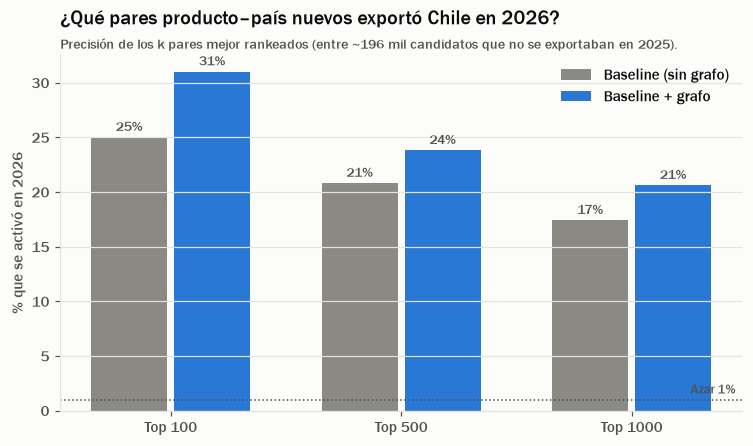

In [16]:
ks = [100, 500, 1000]
fig, ax = plt.subplots(figsize=(8, 4.2))
xx = np.arange(len(ks)); wdt = 0.36
for i, (name, colr) in enumerate([("Baseline (sin grafo)", viz.NEUTRAL), ("Baseline + grafo", viz.EXPORT)]):
    vals = [100 * test_res.loc[name, f"precisión@{k_}"] for k_ in ks]
    ax.bar(xx + (i - 0.5) * wdt, vals, width=wdt - 0.03, color=colr, label=name)
    for x_, v in zip(xx + (i - 0.5) * wdt, vals):
        ax.text(x_, v + 0.6, f"{v:.0f}%", ha="center", fontsize=9, color=viz.TEXT_2)
base_rate = 100 * yt.mean()
ax.axhline(base_rate, color=viz.TEXT_2, ls=":", lw=1)
ax.text(xx[-1] + 0.45, base_rate + 0.6, f"Azar {base_rate:.0f}%", fontsize=8.5, color=viz.TEXT_2, ha="right")
ax.set_xticks(xx, [f"Top {k_}" for k_ in ks]); ax.set_ylabel("% que se activó en 2026")
ax.legend(loc="upper right")
ax.set_title("¿Qué pares producto–país nuevos exportó Chile en 2026?")
viz.subtitle(ax, "Precisión de los k pares mejor rankeados (entre ~196 mil candidatos que no se exportaban en 2025).")
viz.save(fig, "11_activacion_precision"); fig

In [17]:
te["score"] = scores["Baseline + grafo"]
hits = te.sort_values("score", ascending=False).head(100).query("activa == 1").head(10)
hits.assign(producto=hits.hs6.map(lambda h: ETQ.get(h, h).title()), destino=hits.pais.map(lambda c: PAIS.get(c, c).title()),
            **{"valor 2026 (US$)": hits.valor_target.round(0)})[["producto", "destino", "densidad", "score", "valor 2026 (US$)"]].round(3)

,producto,destino,densidad,score,valor 2026 (US$)
160267,Eje,Brasil,0.745,0.702,62119.0
132931,Tapas Pell Off,Estados Unidos De América,0.769,0.702,11126.0
191986,Armario,Brasil,0.730,0.700,41119.0
146071,Equipo Fullcover,Bolivia,0.516,0.700,21058.0
162851,Motor Electrico,Colombia,0.540,0.699,67271.0
41999,Sangria,Argentina,0.499,0.699,21600.0
41998,Sangria,Uruguay,0.798,0.682,11286.0
146069,Equipo Fullcover,Mexico,0.650,0.682,413397.0
170405,Camara Fotografica,Mexico,0.649,0.680,32786.0
139346,Sistema De Lanzas Tipo,Ecuador,0.463,0.673,14763.0


**Lectura del test:**
- El resultado de validación **se replica** en datos nunca vistos: la AP sube ~17% al agregar el grafo, con
  un intervalo de confianza que excluye el cero.
- **En términos de negocio:** de los 1.000 pares mejor rankeados que Chile no exportaba en 2025, ~21% se
  exportó en 2026, frente a ~1% al azar: un *lift* de ~20×. El grafo agrega varias decenas de aciertos sobre
  el baseline dentro de esos 1.000.
- **La densidad sola rankea mal el top:** encuentra pares "plausibles" en mercados pequeños donde casi
  nunca pasa nada. Combinada con el tamaño del mercado, aporta su valor. **El grafo complementa a las
  variables simples, no las reemplaza.**
- Los aciertos son en su mayoría **manufacturas hacia Latinoamérica** (equipos para minería, motores,
  componentes), coherentes con la comunidad de manufactura regional.

**Uso práctico:** una agencia de promoción de exportaciones podría priorizar, para cada empresa o producto,
los mercados con mayor densidad: dónde ya se venden productos relacionados.

## 6. Conclusiones y uso en las etapas siguientes

1. El grafo de capacidades tiene **estructura comunitaria fuerte y estable** (modularidad 0,76; ARI 0,90).
   Sus comunidades corresponden a ecosistemas productivos reales que **cruzan la clasificación arancelaria**.
2. Permite análisis de **riesgo por ecosistema** (dependencia de China) e identificar **productos puente**.
3. **Aporta información predictiva verificada fuera de tiempo:** +17% de AP sobre un baseline fuerte para
   anticipar la apertura de nuevos pares producto–mercado.
4. **Siguiente uso:** la densidad de relatedness y la comunidad del producto se incorporan como features del
   **Problema 2** (clasificación de actividad), recalculadas en cada origen temporal **solo con datos
   pasados**, para no introducir data leakage.

**Limitaciones:** el grafo usa solo exportaciones de Chile (no hay datos mundiales); las etiquetas de
productos se derivan del texto libre de las declaraciones y pueden ser imperfectas; las comunidades
dependen de los umbrales (aunque los resultados predictivos son robustos a ellos).

In [18]:
nodos = pd.DataFrame({"comunidad": com, "comunidad_nombre": com.map(comunidades["nombre"]), "participacion": P,
                      "grado": pd.Series(dict(Gc.degree())), "fuerza": pd.Series(dict(Gc.degree(weight="phi"))),
                      "valor_2025_usd": valor25.reindex(com.index), "etiqueta": ETQ.reindex(com.index)})
nodos.rename_axis("hs6").to_parquet(PROCESSED / "grafo_2025_nodos.parquet")
prox.edges().to_parquet(PROCESSED / "grafo_2025_aristas.parquet")
print(f"Guardado: {len(nodos)} nodos, {Gc.number_of_edges()} aristas")

Guardado: 1116 nodos, 21008 aristas
